In [56]:
import json

import agama
import gc_utils
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.ndimage import gaussian_filter1d

In [57]:
def get_halo_center(part, halt, sim, sim_dir, snapshot):
    # check if centering should be on dm halo
    sim_codes = sim_dir + "simulation_codes.json"
    with open(sim_codes) as sim_json:
        sim_data = json.load(sim_json)
    main_halo_tid = sim_data[sim]["halo"]

    not_host_snap_lst = gc_utils.get_different_snap_lst(main_halo_tid, halt, sim, sim_dir)

    # is the MW progenitor is the main host at this snapshot
    is_main_host = snapshot not in not_host_snap_lst

    halt_center_snap_lst = sim_data[sim]["dm_center"]
    use_dm_center = snapshot in halt_center_snap_lst

    # if the halo is not the host at this snapshot or it has been flagged to use dm center at this snapshot
    if (not is_main_host) or (use_dm_center):
        # get MW progenitor halo details at this snapshot
        halo_tid = gc_utils.get_main_prog_at_snap(halt, main_halo_tid, snapshot)

        if use_dm_center:
            halo_detail_dict = gc_utils.get_dm_halo_details(part, halt, halo_tid, snapshot, True)
        else:
            halo_detail_dict = gc_utils.get_halo_details(part, halt, halo_tid, snapshot)

        return_dict = {"use_host_prop": False, "halo_details": halo_detail_dict}

    else:
        return_dict = {"use_host_prop": True}

    return return_dict

In [58]:
def calc_circularity(snap, pos_xyz, vel_xyz, sim, sim_dir):
    potential_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)

    agama.setUnits(mass=1, length=1, velocity=1)
    pot_nbody = agama.Potential(potential_file)
    af = agama.ActionFinder(pot_nbody, interp=False)

    init_cond = np.hstack((pos_xyz, vel_xyz))

    ioms = af(init_cond)
    jphi = ioms[:, 2]

    ep_agama = pot_nbody.potential(np.array(init_cond)[:, 0:3])
    ek = 0.5 * np.linalg.norm(vel_xyz, axis=1) ** 2
    et = ep_agama + ek

    r_circs = pot_nbody.Rcirc(E=et)
    xyz = np.column_stack((r_circs, r_circs * 0, r_circs * 0))
    v_circs = np.sqrt(-r_circs * pot_nbody.force(xyz)[:, 0])
    vel = np.column_stack((v_circs * 0, v_circs, v_circs * 0))
    init_conds = np.concatenate((xyz, vel), axis=1)
    lz_circ = af(init_conds)[:, 2]

    circ = jphi / lz_circ

    return circ

In [59]:
def get_circularity(
    halt,
    part,
    sim: str,
    sim_dir: str,
    snapshot: int,
    r_limit: float,
    disk_ptypes: list[str] = ["star", "gas"],
    log_t_max: float = 4.5,
):
    host_return_dict = get_halo_center(part, halt, sim, sim_dir, snapshot)

    # create dict
    circ_dict = {}

    if "star" in disk_ptypes:
        if host_return_dict["use_host_prop"]:
            # only select stars within r_limit
            star_mask = part["star"].prop("host.distance.principal.total") < r_limit

            # get 3D positions and velocities
            vel_xyz_star = part["star"].prop("host.velocity.principal")[star_mask]
            pos_xyz_star = part["star"].prop("host.distance.principal")[star_mask]

            vel_sph_star = part["star"].prop("host.velocity.spherical")[star_mask]
            vel_cyl_star = part["star"].prop("host.velocity.cylindrical")[star_mask]

            # star mass
            star_mass = part["star"]["mass"][star_mask]
            star_age = part["star"].prop("age")[star_mask]

        else:
            halo_detail_dict = host_return_dict["halo_details"]

            # only select stars within r_limit
            star_pos_mask = (
                ut.particle.get_distances_wrt_center(
                    part,
                    species=["star"],
                    center_position=halo_detail_dict["position"],
                    rotation=halo_detail_dict["rotation"],
                    coordinate_system="cartesian",
                    total_distance=True,
                )
                < r_limit
            )

            # get 3D positions and velocities
            vel_xyz_star = ut.particle.get_velocities_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_velocity=False,
            )[star_pos_mask]

            pos_xyz_star = ut.particle.get_distances_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=False,
            )[star_pos_mask]

            vel_sph_star = ut.particle.get_velocities_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="spherical",
                total_velocity=False,
            )[star_pos_mask]

            vel_cyl_star = ut.particle.get_velocities_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cylindrical",
                total_velocity=False,
            )[star_pos_mask]

            # star mass
            star_mass = part["star"]["mass"][star_pos_mask]
            star_age = part["star"].prop("age")[star_pos_mask]

        circ_star = calc_circularity(snapshot, pos_xyz_star, vel_xyz_star, sim, sim_dir)

        circ_dict["star"] = {}
        circ_dict["star"]["mass"] = star_mass
        circ_dict["star"]["circularity"] = circ_star
        circ_dict["star"]["age"] = star_age
        circ_dict["star"]["vel.sph"] = vel_sph_star
        circ_dict["star"]["vel.cyl"] = vel_cyl_star

    if "gas" in disk_ptypes:
        # only select gas particles within r_limit
        gas_tem_mask = np.log10(part["gas"]["temperature"]) < log_t_max

        if host_return_dict["use_host_prop"]:
            # only select gas within r_limit
            gas_pos_mask = part["gas"].prop("host.distance.principal.total") < r_limit

            # get 3D positions and velocities
            vel_xyz_gas = part["gas"].prop("host.velocity.principal")[gas_pos_mask & gas_tem_mask]
            pos_xyz_gas = part["gas"].prop("host.distance.principal")[gas_pos_mask & gas_tem_mask]

            # gas mass
            gas_mass = part["gas"]["mass"][gas_pos_mask & gas_tem_mask]

        else:
            halo_detail_dict = host_return_dict["halo_details"]

            # only select gas within r_limit
            gas_pos_mask = (
                ut.particle.get_distances_wrt_center(
                    part,
                    species=["gas"],
                    center_position=halo_detail_dict["position"],
                    rotation=halo_detail_dict["rotation"],
                    coordinate_system="cartesian",
                    total_distance=True,
                )
                < r_limit
            )

            # get 3D positions and velocities
            vel_xyz_gas = ut.particle.get_velocities_wrt_center(
                part,
                species=["gas"],
                center_position=halo_detail_dict["position"],
                center_velocity=halo_detail_dict["velocity"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_velocity=False,
            )[gas_pos_mask & gas_tem_mask]

            pos_xyz_gas = ut.particle.get_distances_wrt_center(
                part,
                species=["gas"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=False,
            )[gas_pos_mask & gas_tem_mask]

            # gas mass
            gas_mass = part["gas"]["mass"][gas_pos_mask & gas_tem_mask]

        circ_gas = calc_circularity(snapshot, pos_xyz_gas, vel_xyz_gas, sim, sim_dir)

        circ_dict["gas"] = {}
        circ_dict["gas"]["mass"] = gas_mass
        circ_dict["gas"]["circularity"] = circ_gas

    return circ_dict

In [60]:
sim = "m12m"
snap = 600

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

# halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
halt = gc_utils.get_halo_tree(sim, sim_dir, species=["star"])
part = gc_utils.open_snapshot(snap, fire_dir, ["star"])

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:21<00:00, 21.25s/it]


In [61]:
# r_lim = 5  # kpc

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

halo_tid = sim_data[sim]["halo"]
halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
r_50 = halt["star.radius.50"][halo_tidx]

circ_dict = get_circularity(halt, part, sim, sim_dir, snap, r_50, disk_ptypes="star")

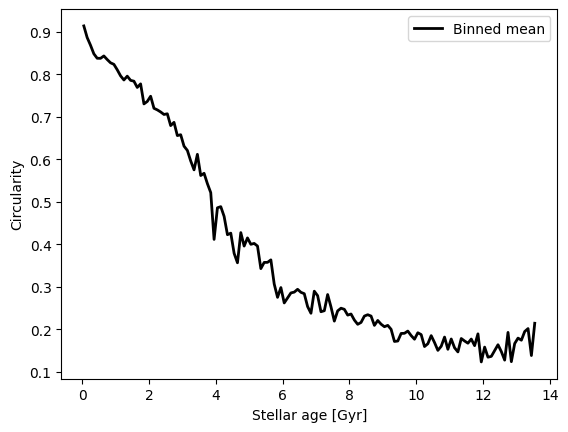

In [62]:
bins = np.arange(0, 13.9, 0.1)

ages = circ_dict["star"]["age"]
circs = circ_dict["star"]["circularity"]

bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
mean_circ = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        # mean_circ[i - 1] = circs[mask].mean()
        mean_circ[i - 1] = np.mean(circs[mask])


plt.plot(bin_centers, mean_circ, lw=2, color="k", label="Binned mean")

plt.xlabel("Stellar age [Gyr]")
plt.ylabel("Circularity")
plt.legend()

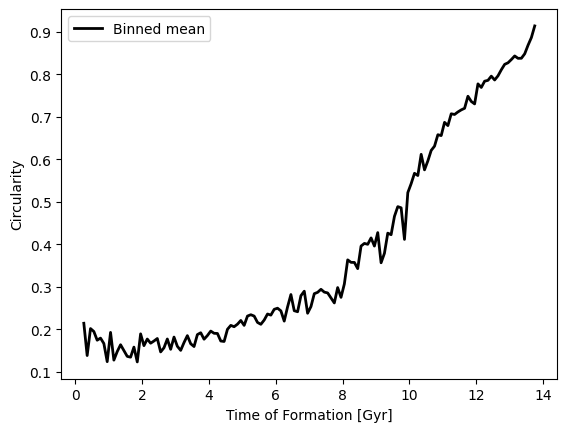

In [63]:
plt.plot(13.8 - bin_centers, mean_circ, lw=2, color="k", label="Binned mean")

plt.xlabel("Time of Formation [Gyr]")
plt.ylabel("Circularity")
plt.legend()

In [64]:
bins = np.arange(0, 13.9, 0.1)

ages = circ_dict["star"]["age"]
v0 = circ_dict["star"]["vel.sph"][:, 0]
v1 = circ_dict["star"]["vel.sph"][:, 1]
v2 = circ_dict["star"]["vel.sph"][:, 2]

bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
disp_0 = np.full(len(bin_centers), np.nan)
disp_1 = np.full(len(bin_centers), np.nan)
disp_2 = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        # mean_circ[i - 1] = circs[mask].mean()
        disp_0[i - 1] = np.std(v0[mask])
        disp_1[i - 1] = np.std(v1[mask])
        disp_2[i - 1] = np.std(v2[mask])

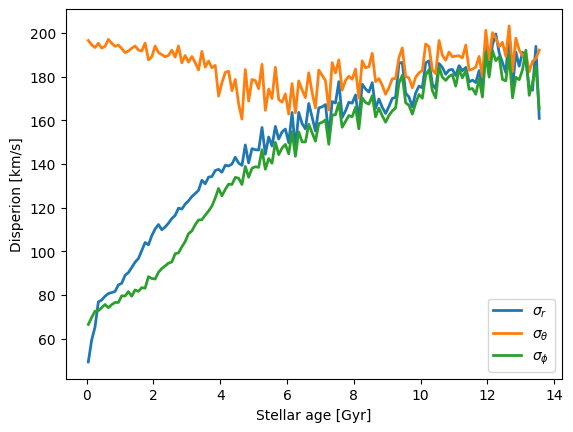

In [65]:
# spherical : r , angle theta, angle phi

plt.plot(bin_centers, disp_0, lw=2, label=r"$\sigma_{r}$")
plt.plot(bin_centers, disp_1, lw=2, label=r"$\sigma_{\theta}$")
plt.plot(bin_centers, disp_2, lw=2, label=r"$\sigma_{\phi}$")

plt.xlabel("Stellar age [Gyr]")
plt.ylabel("Disperion [km/s]")
plt.legend()

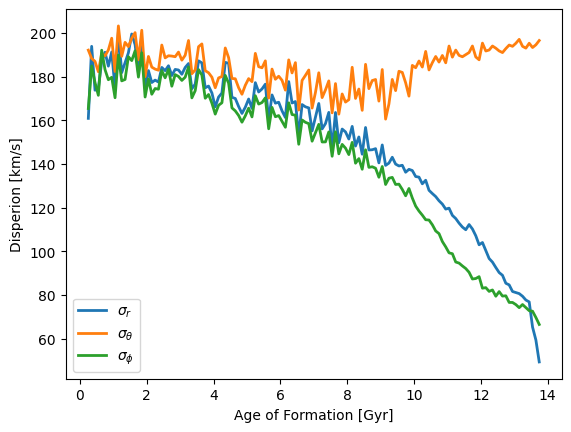

In [66]:
# spherical : r , angle theta, angle phi

plt.plot(13.8 - bin_centers, disp_0, lw=2, label=r"$\sigma_{r}$")
plt.plot(13.8 - bin_centers, disp_1, lw=2, label=r"$\sigma_{\theta}$")
plt.plot(13.8 - bin_centers, disp_2, lw=2, label=r"$\sigma_{\phi}$")

plt.xlabel("Age of Formation [Gyr]")
plt.ylabel("Disperion [km/s]")
plt.legend()

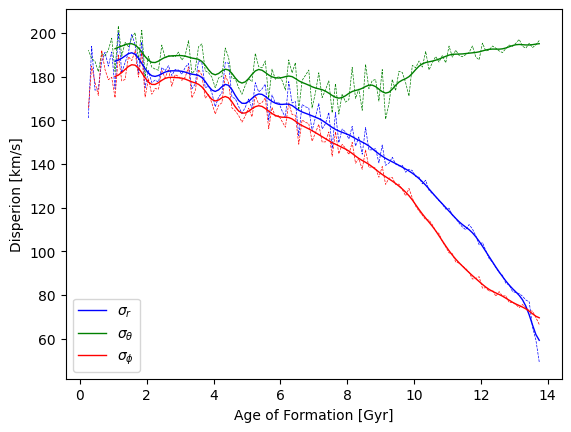

In [67]:
disp_0s = gaussian_filter1d(disp_0, sigma=2)
disp_1s = gaussian_filter1d(disp_1, sigma=2)
disp_2s = gaussian_filter1d(disp_2, sigma=2)

plt.plot(13.8 - bin_centers, disp_0, c="b", lw=0.5, ls="--")
plt.plot(13.8 - bin_centers, disp_1, c="g", lw=0.5, ls="--")
plt.plot(13.8 - bin_centers, disp_2, c="r", lw=0.5, ls="--")


plt.plot(13.8 - bin_centers, disp_0s, c="b", lw=1, label=r"$\sigma_{r}$")
plt.plot(13.8 - bin_centers, disp_1s, c="g", lw=1, label=r"$\sigma_{\theta}$")
plt.plot(13.8 - bin_centers, disp_2s, c="r", lw=1, label=r"$\sigma_{\phi}$")

plt.xlabel("Age of Formation [Gyr]")
plt.ylabel("Disperion [km/s]")
plt.legend()

In [68]:
bins = np.arange(0, 13.9, 0.1)

ages = circ_dict["star"]["age"]
v0 = circ_dict["star"]["vel.sph"][:, 0]
v1 = circ_dict["star"]["vel.sph"][:, 1]
v2 = circ_dict["star"]["vel.sph"][:, 2]

bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
v_rot = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        # mean_circ[i - 1] = circs[mask].mean()
        disp = np.sqrt(np.std(v0[mask]) ** 2 + np.std(v1[mask]) ** 2 + np.std(v2[mask]) ** 2)
        v_rot[i - 1] = np.mean(v2[mask]) / disp

Text(0, 0.5, 'V / $\\sigma$')

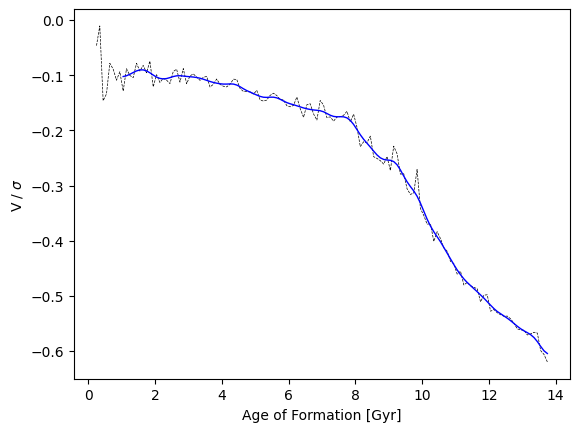

In [69]:
v_rots = gaussian_filter1d(v_rot, sigma=2)

plt.plot(13.8 - bin_centers, v_rot, c="k", lw=0.5, ls="--")
plt.plot(13.8 - bin_centers, v_rots, c="b", lw=1)

plt.xlabel("Age of Formation [Gyr]")
plt.ylabel(r"V / $\sigma$")
# plt.legend()

(1.0, 13.8)

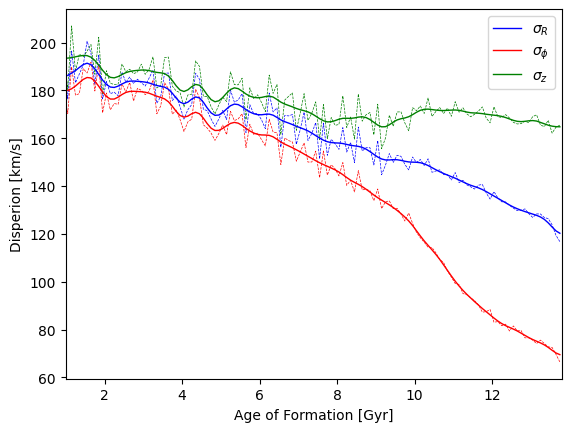

In [70]:
bins = np.arange(0, 13.9, 0.1)

ages = circ_dict["star"]["age"]
v0 = circ_dict["star"]["vel.cyl"][:, 0]
v1 = circ_dict["star"]["vel.cyl"][:, 1]
v2 = circ_dict["star"]["vel.cyl"][:, 2]

bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
disp_0 = np.full(len(bin_centers), np.nan)
disp_1 = np.full(len(bin_centers), np.nan)
disp_2 = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        # mean_circ[i - 1] = circs[mask].mean()
        disp_0[i - 1] = np.std(v0[mask])
        disp_1[i - 1] = np.std(v1[mask])
        disp_2[i - 1] = np.std(v2[mask])

disp_0s = gaussian_filter1d(disp_0, sigma=2)
disp_1s = gaussian_filter1d(disp_1, sigma=2)
disp_2s = gaussian_filter1d(disp_2, sigma=2)

plt.plot(13.8 - bin_centers, disp_0, c="b", lw=0.5, ls="--")
plt.plot(13.8 - bin_centers, disp_1, c="r", lw=0.5, ls="--")
plt.plot(13.8 - bin_centers, disp_2, c="g", lw=0.5, ls="--")


plt.plot(13.8 - bin_centers, disp_0s, c="b", lw=1, label=r"$\sigma_{R}$")
plt.plot(13.8 - bin_centers, disp_1s, c="r", lw=1, label=r"$\sigma_{\phi}$")
plt.plot(13.8 - bin_centers, disp_2s, c="g", lw=1, label=r"$\sigma_{z}$")

plt.xlabel("Age of Formation [Gyr]")
plt.ylabel("Disperion [km/s]")
plt.legend()

plt.xlim(1, 13.8)